Note: I did most of Q1 in R to grow in my knowledge of R. That code is not included here since it was distinct from the group submission. However, it formed the backbone of my preprocessing here.

# Initialization

In [ ]:
# Install system dependencies first
system("apt-get update -qq")
system("apt-get install -y libmagick++-dev")

In [ ]:
install.packages("GGally")
install.packages("plotly")
install.packages("summarytools")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lobstr’, ‘plyr’, ‘reshape2’, ‘checkmate’, ‘magick’, ‘matrixStats’, ‘pander’, ‘pryr’, ‘rapportools’




In [ ]:
install.packages("summarytools")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(tidyverse)
library(ggplot2)
library(GGally)
library(plotly)
library(summarytools)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout


Warning message:
“no DISPLAY variable so Tk is not available”

Attaching package: ‘summarytools’


The following object is masked from ‘package:tibble’:

    view




# Part A


Summarize the data. How much data is present? What attributes/features are continuous valued? Which attributes are categorical? [5 points]

In [ ]:
data <- read.csv("possum.csv")

In [ ]:
str(data)

'data.frame':	104 obs. of  14 variables:
 $ case    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ site    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ Pop     : chr  "Vic" "Vic" "Vic" "Vic" ...
 $ sex     : chr  "m" "f" "f" "f" ...
 $ age     : int  8 6 6 6 2 1 2 6 9 6 ...
 $ hdlngth : num  94.1 92.5 94 93.2 91.5 93.1 95.3 94.8 93.4 91.8 ...
 $ skullw  : num  60.4 57.6 60 57.1 56.3 54.8 58.2 57.6 56.3 58 ...
 $ totlngth: num  89 91.5 95.5 92 85.5 90.5 89.5 91 91.5 89.5 ...
 $ taill   : num  36 36.5 39 38 36 35.5 36 37 37 37.5 ...
 $ footlgth: num  74.5 72.5 75.4 76.1 71 73.2 71.5 72.7 72.4 70.9 ...
 $ earconch: num  54.5 51.2 51.9 52.2 53.2 53.6 52 53.9 52.9 53.4 ...
 $ eye     : num  15.2 16 15.5 15.2 15.1 14.2 14.2 14.5 15.5 14.4 ...
 $ chest   : num  28 28.5 30 28 28.5 30 30 29 28 27.5 ...
 $ belly   : num  36 33 34 34 33 32 34.5 34 33 32 ...


In [ ]:
na_counts <- data %>%
  summarise_all(~ sum(is.na(.))) %>%
  pivot_longer(everything(), names_to = "Variables", values_to = "Missing") %>%
  arrange(desc(Missing))

print(na_counts)

# A tibble: 14 × 2
   Variables Missing
   <chr>       <int>
 1 age             2
 2 footlgth        1
 3 case            0
 4 site            0
 5 Pop             0
 6 sex             0
 7 hdlngth         0
 8 skullw          0
 9 totlngth        0
10 taill           0
11 earconch        0
12 eye             0
13 chest           0
14 belly           0


There are 104 data points each representing 14 distinct variables. The data appears to be mostly complete, with only 3 entries NA: 2 for *age* and 1 for *foot length*.

*Case*, *Site*, *Population*, and *Sex* are categorical variables. *Age* is reported discretely, but can be considered continuous. All other variables are continuous.

In [ ]:
data <- na.omit(data)
data <- data[ , !(names(data) %in% c("case","site"))]

Since there were so few NA entries, I have simply removed those data points. I am also removing *Case* and *Site* as features since the former is just the index and the latter because it doesn't give us much information. We would have to treat it as categorical, yet we don't know how the categories relate to one another as there is no map of sites.

# Parts B / C


B. Display the statistical values for each of the attributes, along with visualizations (e.g., histogram) of the distributions for each attribute. Explain noticeable traits for key attributes. Are there any attributes that might require special treatment? If so, what special treatment might they require? [5 points]

C. Analyze the relationships between the data attributes, and between the data attributes and label. This involves computing the Pearson Correlation Coefficient (PCC) and generating scatter plots. [10 points]

In [ ]:
# Resize plot window within Colab
options(repr.plot.width = 30, repr.plot.height = 20)

In [ ]:
options(warn=-1)
dfSummary(data) %>%
  print(method = "render")
options(warn=0)

Shiny tags cannot be represented in plain text (need html)

In [ ]:
options(warn=-1) # Suppress Warnings (Null Values)

heatmap <- function(data, mapping, ...) {
  x <- eval_data_col(data, mapping$x)
  y <- eval_data_col(data, mapping$y)

  # Pearson correlation
  p_corr = cor(x, y, use = "complete.obs", method = "pearson")

  # Fill color from correlation using color-mapping function on p_corr
  fill_color <- scales::col_numeric(
    palette = c("purple4","ivory2","orangered3"),
    domain = c(-1,1)
  )(p_corr)

  ggplot(data, mapping) +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -Inf, ymax = Inf,
             fill = fill_color, alpha = 0.9) +
    annotate("text", x = 0.5, y = 0.5,
             label = sprintf("%.2f", p_corr),
             size = 10, fontface = "bold", color = "black") +
    theme_void()
}

fancy_plot <- function(data)
  ggpairs(
    data=data,
    upper = list(continuous = heatmap),
    diag = list(continuous = wrap("barDiag", bins = 25, fill = "royalblue4")),
    lower = list(continuous = wrap("points", alpha = 0.3, size = 0.5)),
    aes()
  ) +
    theme(
      strip.text.x = element_text(size = 20, face = "bold"), # top labels
      strip.text.y = element_text(size = 20, face = "bold"), # right-side labels
      strip.placement = "outside",
      strip.background = element_rect(fill = "white", color = NA)
    )
  options(warn=0)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bi

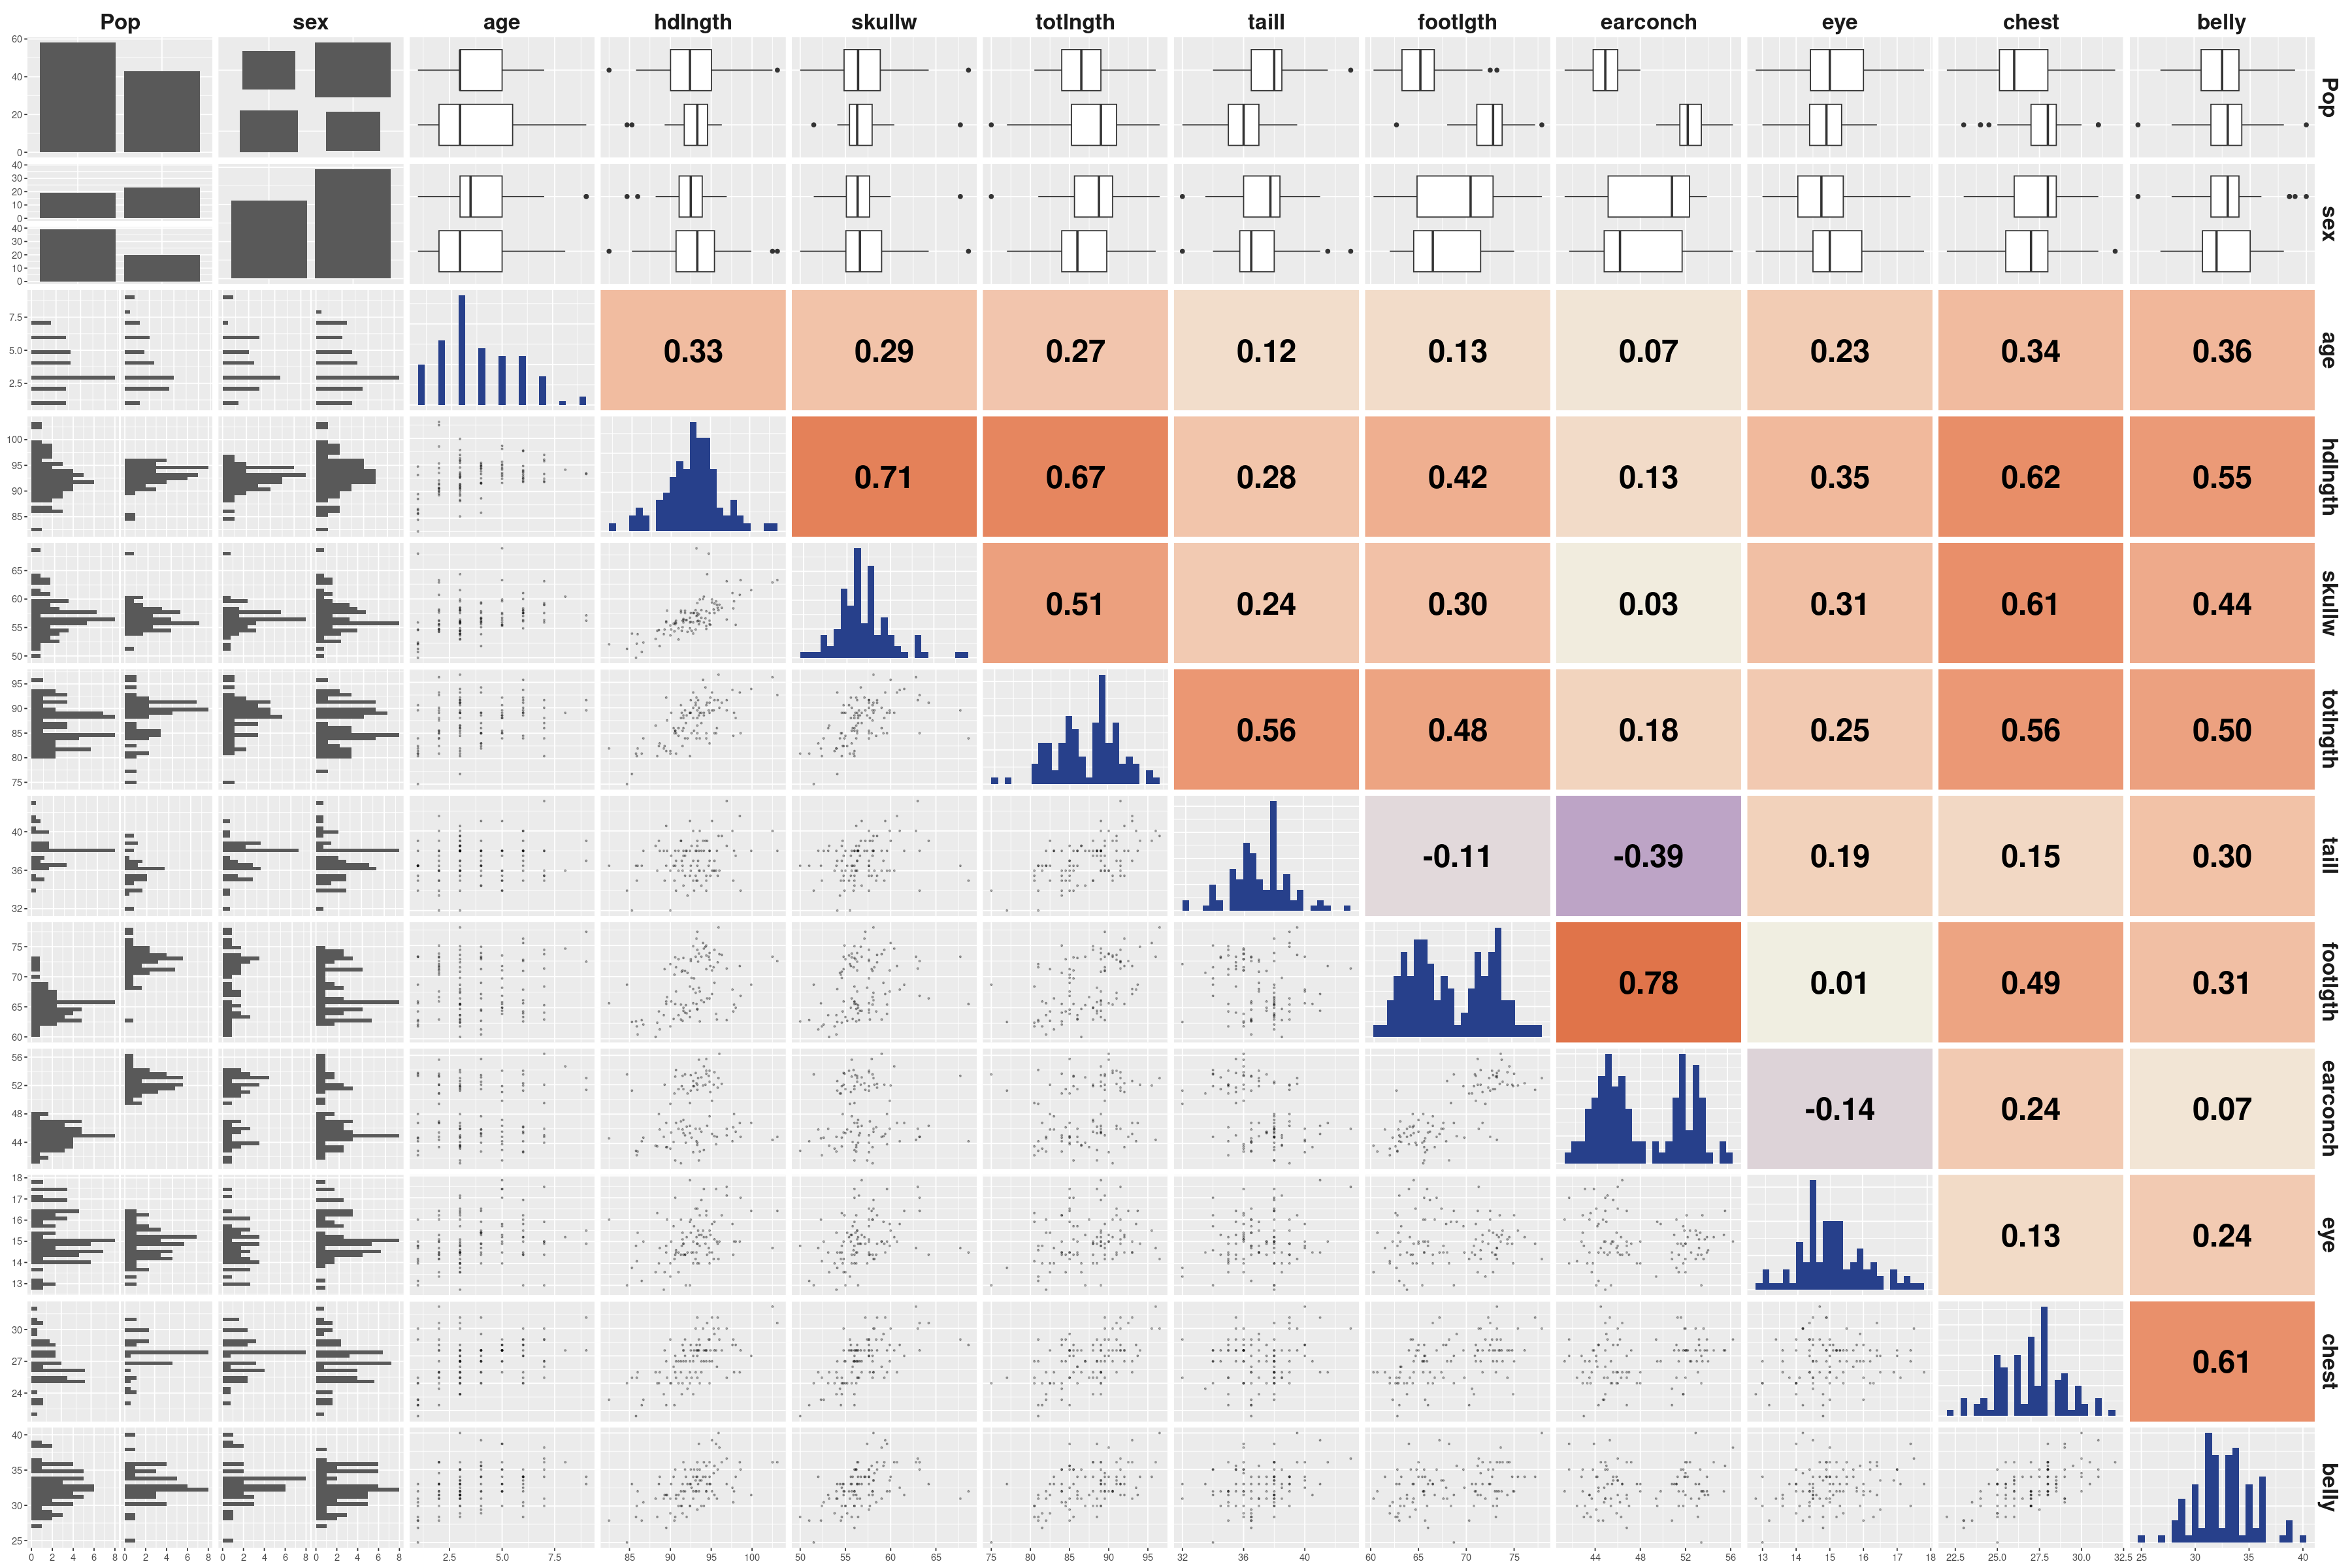

In [ ]:
fancy_plot(data)

The data looks fairly clean. The general bimodal distributions makes sense given the two sexes. There do appear to be outliers in most variables based on the box-and-whisker plots. I will remove them before generating my regression model.

In [ ]:
remove_outliers <- function(df) {
  for (col in names(df)) {
    if (is.numeric(df[[col]])) {
      Q1 <- quantile(df[[col]], 0.25)
      Q3 <- quantile(df[[col]], 0.75)
      IQR = Q3 - Q1

      upper_bound <- Q3 + 1.5 * IQR
      lower_bound <- Q1 - 1.5 * IQR

      df <- df[df[[col]] >= lower_bound & df[[col]] <= upper_bound, ]
    }
  }

  return(df)
}

In [ ]:
df <- remove_outliers(data)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bi

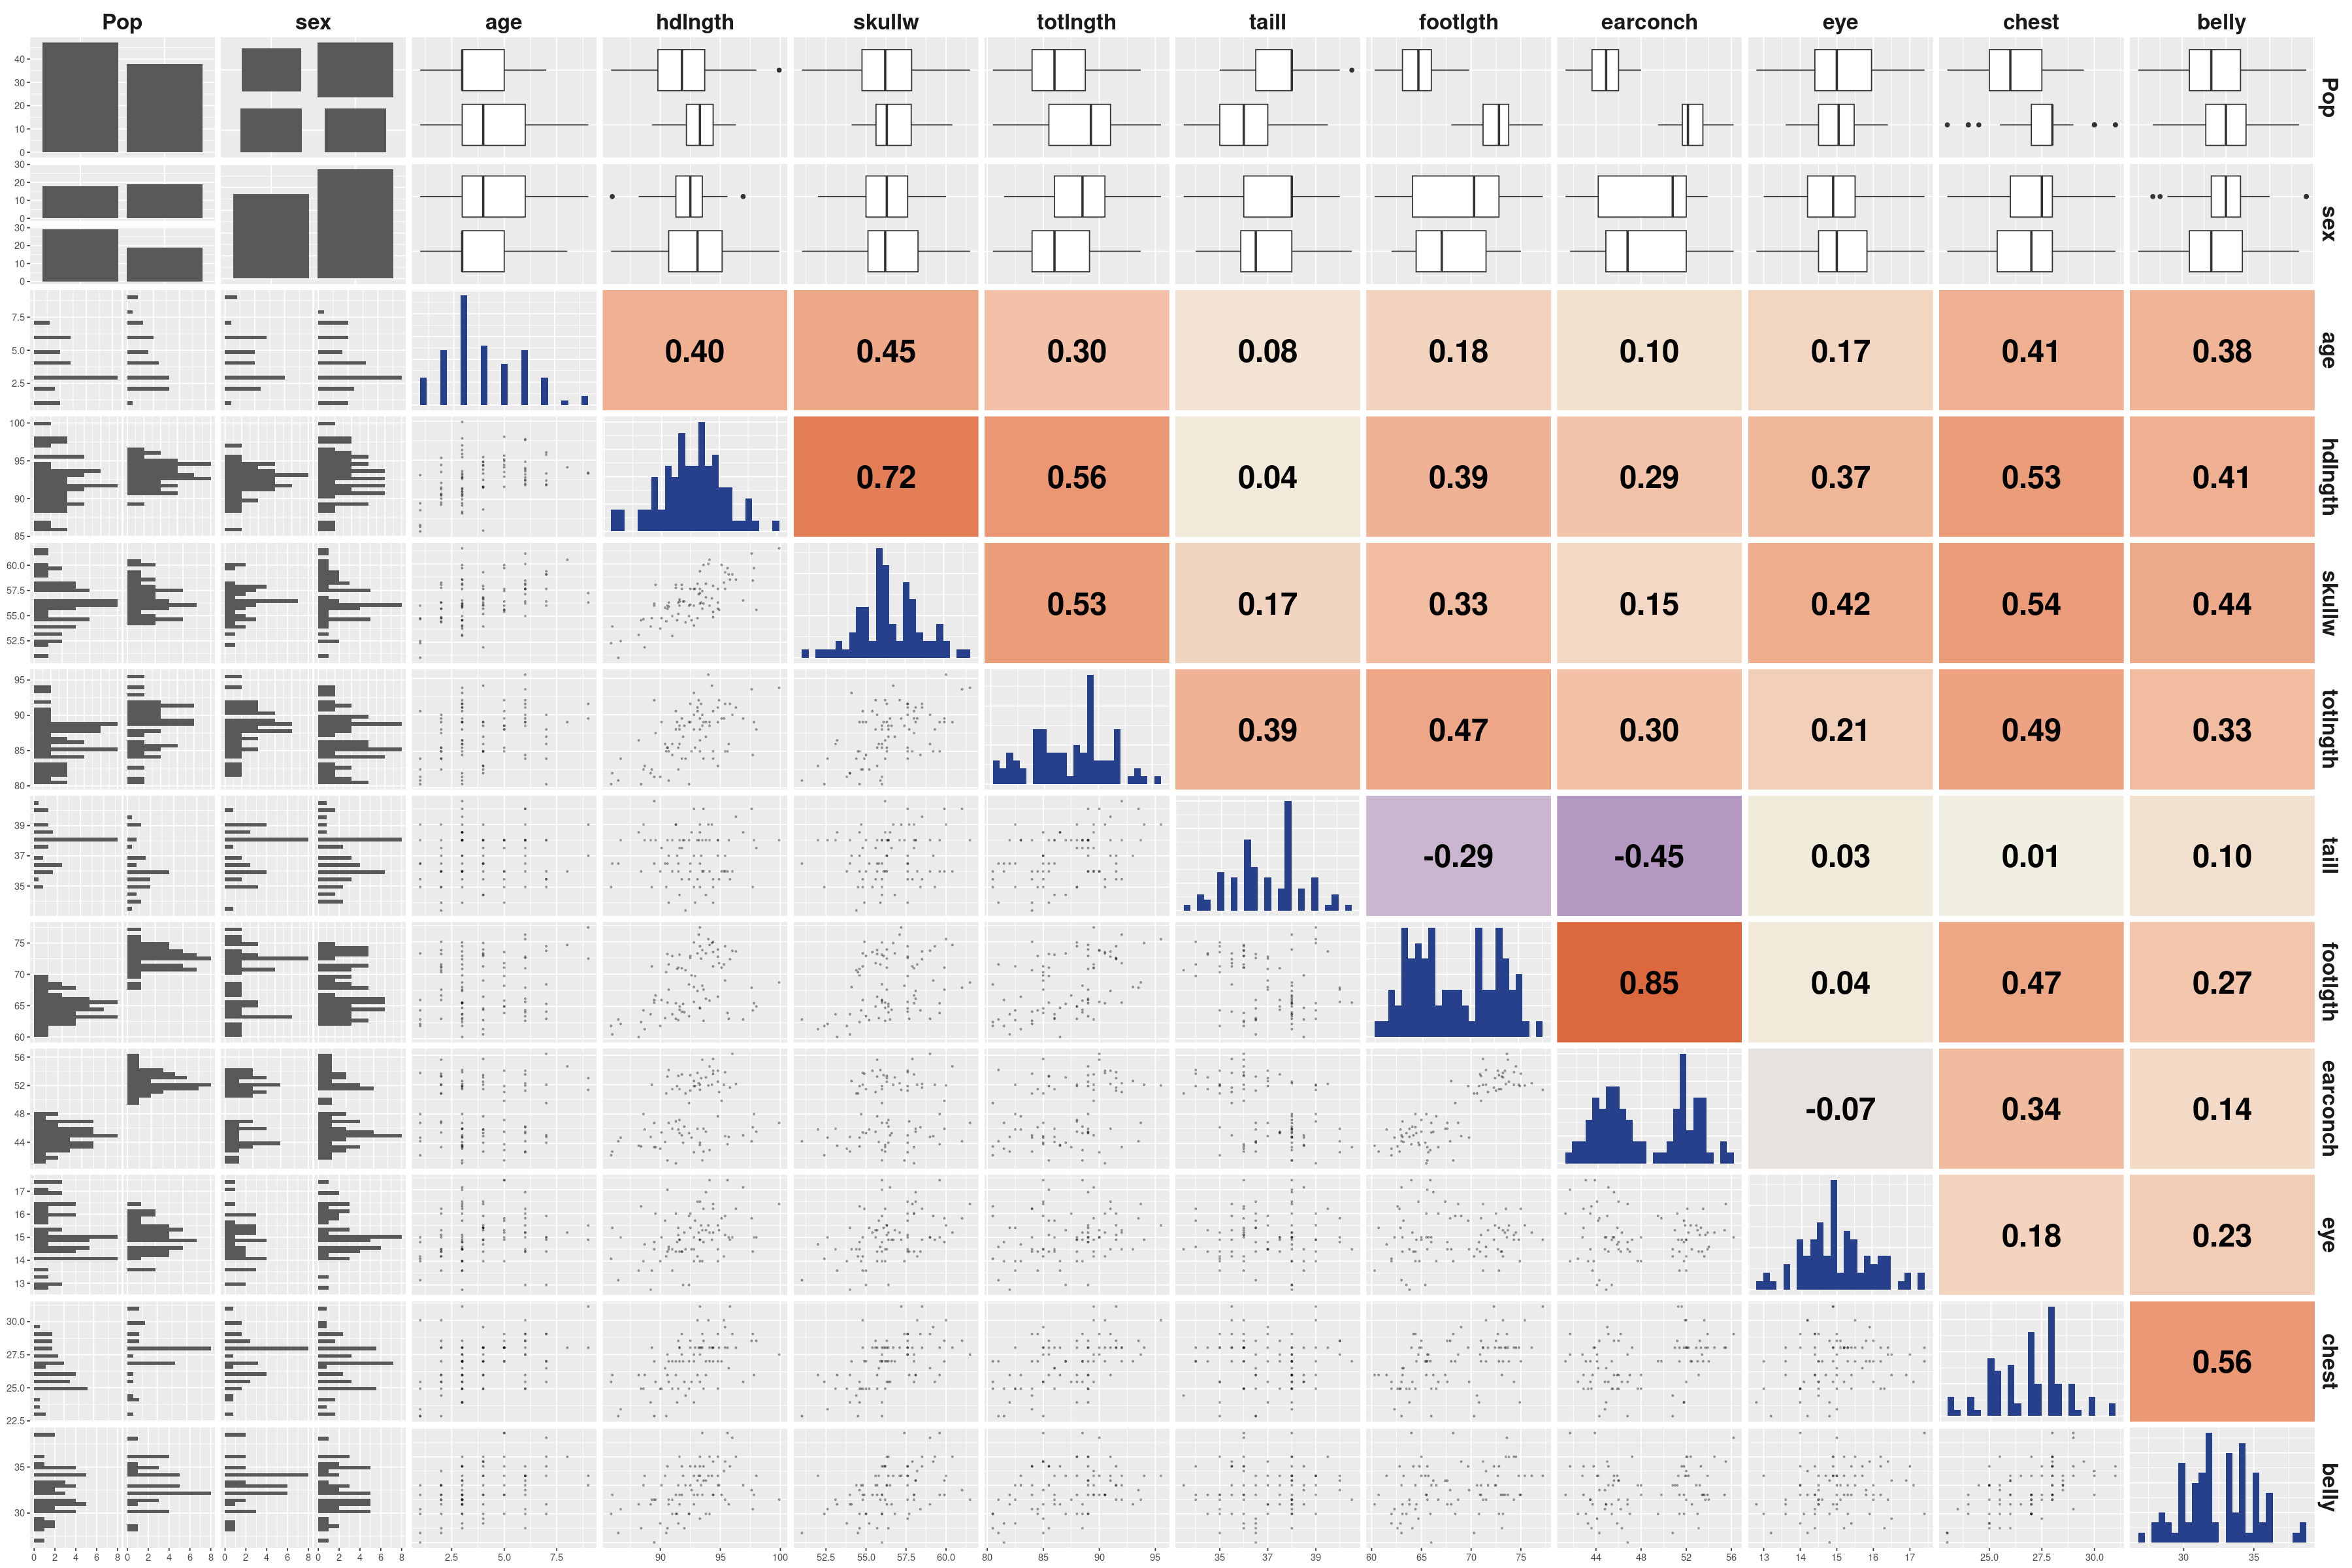

In [ ]:
fancy_plot(df)

Looking at this sanitized dataframe, some of the correlations have grown weaker, with the weakest by far being between belly girth (*chest*) and tail length at 0.01. Yet others have grown stronger, with the strongest between foot length and ear conch length at 0.85.

For my model, because I think it will be interesting, I am going to attempt to use these features to predict the age of the opposum.

In [ ]:
write.csv(df, "possum_filtered.csv")

# References

The following is copy-pasted from my work through of Q1 in R:

The R library pages were instrumental in understanding how each worked, particularly for the ggpairs() function. ChatGPT assisted with some custom functions, such as the heatmap implementation for the Pearson's Coefficient. However, when used for programming elements, the code was always explained or stepped through to improve understanding.

https://www.r-bloggers.com/2021/10/cross-validation-in-r-with-example/

https://www.youtube.com/watch?v=BQ1VAZ7jNYQ

https://www.geeksforgeeks.org/r-language/k-fold-cross-validation-in-r-programming/

https://www.rdocumentation.org/packages/caret/versions/4.47/topics/train

https://medium.com/biased-algorithms/stochastic-gradient-descent-in-r-a692bee650d8

https://www.datacareer.ch/blog/ridge-and-lasso-in-r/